# `multicellular` feature tour

A quick tour of the `multicellular` package: single cells, chemical reaction
networks, the `Environment`/`Field`/diffusion machinery, multi-cell colonies,
and the simulation utilities built on top of them. See the project `README.md`
for the full API reference this notebook is drawn from.

Each section below is self-contained and runs in well under a minute.


In [1]:
import math
import os
import pickle

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import (
    Cell, Colony, Environment, Field, ReactionNetwork, Simulation, run_replicates, visualize,
)
from multicellular.core.reactions import Reaction

os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 100


## 1. `Cell`: geometry, growth, and division

A `Cell` is a spherocylinder (cylinder with hemispherical caps) that grows
exponentially in length and divides once it reaches its sampled "adder"
target — see `Cell.grow` / `Cell.ready_to_divide` / `Cell.divide`.


initial volume: 2.094 um^3
divided at t=0.60 into lengths 1.506 and 1.506


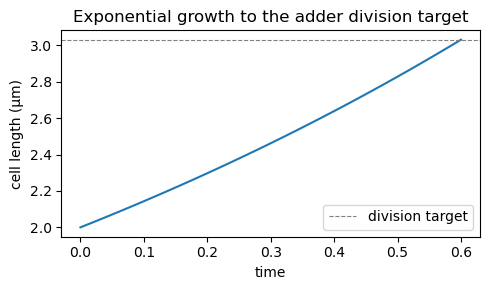

In [2]:
cell = Cell(
    id=0, position=[0.0, 0.0], orientation=[1.0, 0.0],
    length=2.0, radius=0.5, rng=np.random.default_rng(0),
)
print(f"initial volume: {cell.compute_volume():.3f} um^3")

dt = 0.02
times, lengths = [0.0], [cell.length]
daughters = None
while daughters is None:
    cell.grow(dt)
    times.append(times[-1] + dt)
    lengths.append(cell.length)
    daughters = cell.divide()

daughter1, daughter2 = daughters
print(f"divided at t={times[-1]:.2f} into lengths {daughter1.length:.3f} and {daughter2.length:.3f}")

plt.figure(figsize=(5, 3))
plt.plot(times, lengths)
plt.axhline(lengths[-1], color="gray", linestyle="--", linewidth=0.8, label="division target")
plt.xlabel("time")
plt.ylabel("cell length (μm)")
plt.title("Exponential growth to the adder division target")
plt.legend()
plt.tight_layout()
plt.show()


## 2. `Reaction` rate laws

`Reaction` supports four rate law types: `mass_action`, `michaelis_menten`,
`hill_langmuir`, and `custom` (an arbitrary user-supplied function). Here's
each one's rate as a function of its key input.


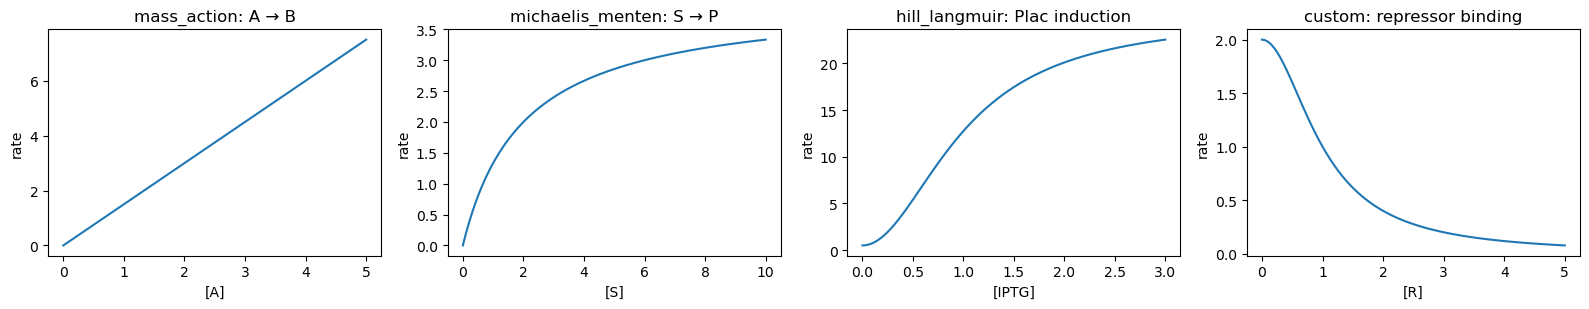

In [3]:
mass_action = Reaction(
    {"A": 1}, {"B": 1}, rate_law_type="mass_action", rate_params={"k": 1.5}
)
michaelis_menten = Reaction(
    {"S": 1}, {"P": 1}, catalysts=["E"],
    rate_law_type="michaelis_menten", rate_params={"Vmax": 4.0, "Km": 2.0},
)
# Plac-style induction: rate rises with inducer [IPTG] (the 2nd catalyst)
hill_langmuir = Reaction(
    {}, {"GFP": 1}, catalysts=["RNAP", "IPTG"],
    rate_law_type="hill_langmuir",
    rate_params={"alpha": 50.0, "beta": 0.5, "C": 1.0, "n": 2},
)

def repressor_binding(reactant_conc, product_conc, catalyst_conc, rate_params):
    repressor = catalyst_conc.get("R", 0.0)
    return rate_params["k"] / (1.0 + (repressor / rate_params["K"]) ** 2)

custom = Reaction(
    {}, {"mRNA": 1}, catalysts=["R"],
    rate_law_type="custom", custom_rate_law=repressor_binding,
    rate_params={"k": 2.0, "K": 1.0},
)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.2))

A = np.linspace(0, 5, 100)
axes[0].plot(A, [mass_action.rate({"A": a}) for a in A])
axes[0].set(title="mass_action: A → B", xlabel="[A]", ylabel="rate")

S = np.linspace(0, 10, 100)
axes[1].plot(S, [michaelis_menten.rate({"S": s, "E": 1.0}) for s in S])
axes[1].set(title="michaelis_menten: S → P", xlabel="[S]", ylabel="rate")

iptg = np.linspace(0, 3, 100)
axes[2].plot(iptg, [hill_langmuir.rate({"RNAP": 1.0, "IPTG": z}) for z in iptg])
axes[2].set(title="hill_langmuir: Plac induction", xlabel="[IPTG]", ylabel="rate")

repressor = np.linspace(0, 5, 100)
axes[3].plot(repressor, [custom.rate({"R": r}) for r in repressor])
axes[3].set(title="custom: repressor binding", xlabel="[R]", ylabel="rate")

fig.tight_layout()
plt.show()


## 3. A chemical reaction network inside a cell that doesn't grow

Setting `growth_rate=0.0` isolates the reaction kinetics from growth
dilution. Here a reversible isomerization `A <-> B` relaxes to its
equilibrium ratio `[B]/[A] = k_fwd / k_rev`.


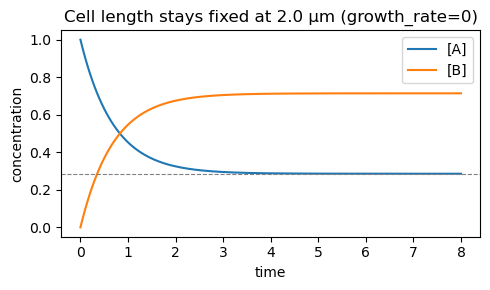

In [4]:
forward = Reaction({"A": 1}, {"B": 1}, rate_law_type="mass_action", rate_params={"k": 1.0})
reverse = Reaction({"B": 1}, {"A": 1}, rate_law_type="mass_action", rate_params={"k": 0.4})
network = ReactionNetwork("isomerization", {"forward": forward, "reverse": reverse})

cell = Cell(
    id=0, position=[5.0, 5.0], orientation=[1.0, 0.0],
    network=network, growth_rate=0.0, rng=np.random.default_rng(0),
)
cell.set_concentration("A", 1.0)
cell.set_concentration("B", 0.0)

colony = Colony([cell], Environment("env", shape=(5, 5), bounds=(10.0, 10.0)))
sim = Simulation(colony, dt=0.05, t_max=8.0)
df = sim.run(show_progress=False)

equilibrium_A = 0.4 / 1.4  # k_rev / (k_fwd + k_rev), total concentration = 1
plt.figure(figsize=(5, 3))
plt.plot(df["time"], df["A"], label="[A]")
plt.plot(df["time"], df["B"], label="[B]")
plt.axhline(equilibrium_A, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("time")
plt.ylabel("concentration")
plt.title(f"Cell length stays fixed at {cell.length:.1f} μm (growth_rate=0)")
plt.legend()
plt.tight_layout()
plt.show()


## 4. All three simulation methods: ODE, CLE, and SSA

`Simulation`'s `simulation_method` can be `"ODE"` (forward Euler),
`"CLE"` (chemical Langevin equation), or `"SSA"` (Gillespie). All three
share the same `Reaction.rate()` definitions; a small cell volume makes
the SSA/CLE molecular noise visible against the deterministic ODE curve.
A birth-death process (zeroth-order synthesis, first-order degradation)
settles to a steady state of `k_synth / k_degrade`.


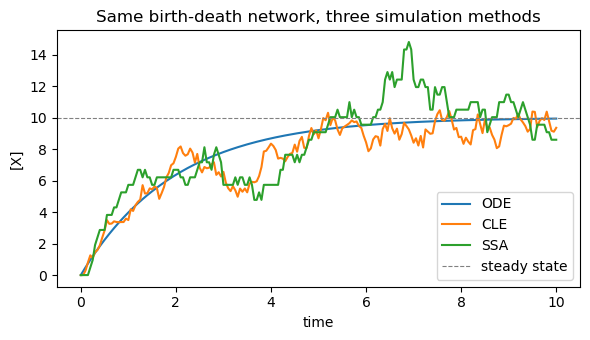

In [5]:
synthesis   = Reaction({},      {"X": 1}, rate_law_type="mass_action", rate_params={"k": 5.0})
degradation = Reaction({"X": 1}, {},      rate_law_type="mass_action", rate_params={"k": 0.5})

plt.figure(figsize=(6, 3.5))
for method in ["ODE", "CLE", "SSA"]:
    network = ReactionNetwork("birth_death", {"synthesis": synthesis, "degradation": degradation})
    cell = Cell(id=0, position=[5.0, 5.0], orientation=[1.0, 0.0],
                network=network, growth_rate=0.0, rng=np.random.default_rng(42))
    cell.set_concentration("X", 0.0)
    df = Simulation(Colony([cell], Environment("env", shape=(5,5), bounds=(10.,10.))),
                    dt=0.05, t_max=10.0, simulation_method=method).run(show_progress=False)
    plt.plot(df["time"], df["X"], label=method)

plt.axhline(5.0 / 0.5, color="gray", linestyle="--", linewidth=0.8, label="steady state")
plt.xlabel("time")
plt.ylabel("[X]")
plt.title("Same birth-death network, three simulation methods")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Dilution by growth

With no reaction network at all, a growing cell's molecule *count* of a
species stays fixed while its *concentration* falls as volume grows — see
`Cell.grow`.


copy number conserved: 2.0944 -> 2.0944


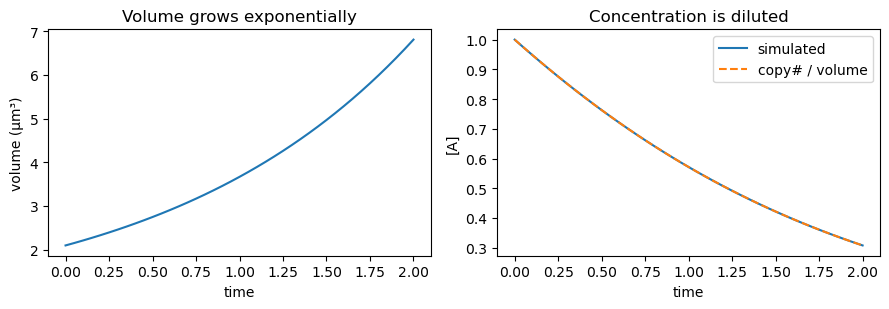

In [6]:
cell = Cell(
    id=0, position=[0.0, 0.0], orientation=[1.0, 0.0], length=2.0,
    growth_rate=np.log(2), rng=np.random.default_rng(0),
)
cell.set_concentration("A", 1.0)
copy_number_at_birth = cell.copy_number("A")

dt, t_max = 0.05, 2.0
times, concentrations, volumes = [0.0], [cell.concentrations["A"]], [cell.compute_volume()]
for _ in range(int(t_max / dt)):
    cell.grow(dt)
    times.append(times[-1] + dt)
    concentrations.append(cell.concentrations["A"])
    volumes.append(cell.compute_volume())

print(f"copy number conserved: {copy_number_at_birth:.4f} -> {cell.copy_number('A'):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.2))
ax1.plot(times, volumes)
ax1.set(xlabel="time", ylabel="volume (μm³)", title="Volume grows exponentially")
ax2.plot(times, concentrations, label="simulated")
ax2.plot(times, copy_number_at_birth / np.array(volumes), "--", label="copy# / volume")
ax2.set(xlabel="time", ylabel="[A]", title="Concentration is diluted")
ax2.legend()
fig.tight_layout()
plt.show()


## 6. Low-copy species: stochastic partitioning at division

Most species are simply copied to both daughters at division (conserving
total copy number since each daughter inherits half the volume). Marking a
species `low_copy=True` instead splits its *copy number* stochastically —
binomial for small counts. Here a plasmid present at 8 copies is split
across many independent divisions.


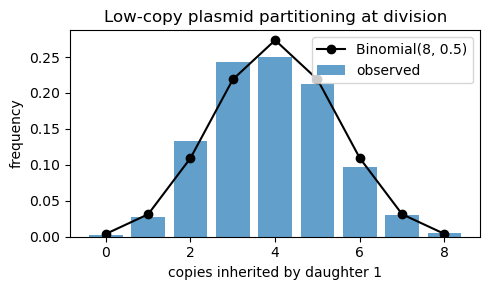

In [7]:
plasmid_copies = 8
n_trials = 400
daughter_counts = []
for trial in range(n_trials):
    cell = Cell(
        id=0, position=[0.0, 0.0], orientation=[1.0, 0.0], length=4.0,
        rng=np.random.default_rng(trial),
    )
    cell.set_concentration("plasmid", plasmid_copies / cell.compute_volume(), low_copy=True)
    cell._division_target = cell.length  # divide immediately for this demo
    daughter1, _ = cell.divide()
    daughter_counts.append(round(daughter1.copy_number("plasmid")))

counts = np.arange(plasmid_copies + 1)
observed    = np.bincount(daughter_counts, minlength=plasmid_copies+1) / n_trials
binomial_pmf = [math.comb(plasmid_copies, k) * 0.5**plasmid_copies for k in counts]

plt.figure(figsize=(5, 3))
plt.bar(counts, observed, alpha=0.7, label="observed")
plt.plot(counts, binomial_pmf, "o-", color="black", label="Binomial(8, 0.5)")
plt.xlabel("copies inherited by daughter 1")
plt.ylabel("frequency")
plt.title("Low-copy plasmid partitioning at division")
plt.legend()
plt.tight_layout()
plt.show()


## 7. `Environment` and `Field`: heterogeneous media

`Environment` carries spatial `diffusivity` and `eta` (viscosity) grids that
set the local drag felt by Brownian motion. Both default to uniform water
at 37°C but can vary spatially, e.g. a more viscous gel region.


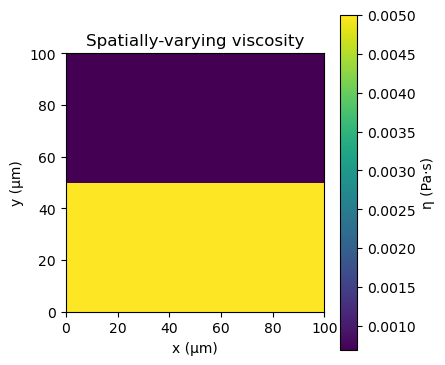

In [8]:
shape = (40, 40)
eta = np.full(shape, 6.9e-4)
eta[:20, :] = 5e-3  # more viscous upper half

env = Environment("Field Demo", shape=shape, bounds=(100.0, 100.0), eta=eta)

plt.figure(figsize=(4.5, 4))
plt.imshow(env.eta, origin="lower", extent=[0, 100, 0, 100], cmap="viridis")
plt.colorbar(label="η (Pa·s)")
plt.xlabel("x (μm)")
plt.ylabel("y (μm)")
plt.title("Spatially-varying viscosity")
plt.tight_layout()
plt.show()


## 8. Pure diffusion of a chemical — no cells at all

A `Field` marked `diffuses=True` evolves under `∂C/∂t = D∇²C` via
`Environment.diffuse()`, independent of any `Colony` or `Cell`. Starting
from a concentrated spot, the chemical spreads out while its total amount
is conserved (no-flux boundaries).


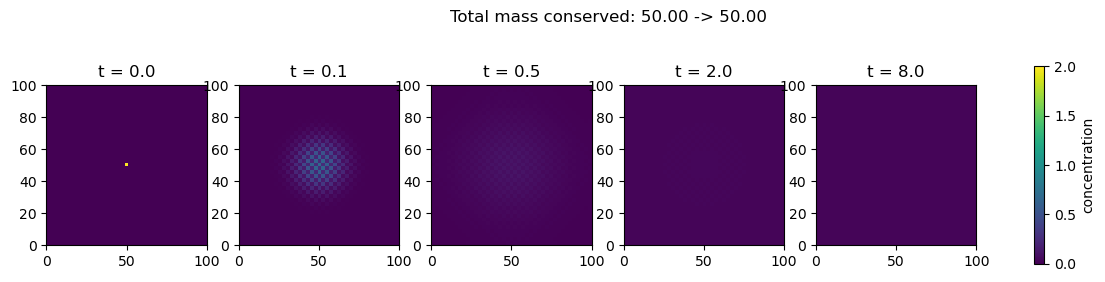

In [9]:
shape = (41, 41)
values = np.zeros(shape)
values[20, 20] = 50.0  # a concentrated drop in the center

dye = Field("dye", values, diffuses=True, diffusivity=5e-10)
env = Environment("Diffusion Demo", shape=shape, bounds=(100.0, 100.0), fields=[dye])

snapshot_times = [0.0, 0.1, 0.5, 2.0, 8.0]
snapshots = {0.0: dye.values.copy()}
t = 0.0
for target_time in snapshot_times[1:]:
    env.diffuse(target_time - t)
    t = target_time
    snapshots[t] = env.get_field("dye").values.copy()

fig, axes = plt.subplots(1, len(snapshots), figsize=(3*len(snapshots), 3.2))
for ax, (snap_time, snap) in zip(axes, snapshots.items()):
    im = ax.imshow(snap, origin="lower", extent=[0, 100, 0, 100], vmin=0, vmax=2.0)
    ax.set_title(f"t = {snap_time}")
fig.colorbar(im, ax=axes, shrink=0.8, label="concentration")
fig.suptitle(f"Total mass conserved: {snapshots[0.0].sum():.2f} -> {snapshots[8.0].sum():.2f}")
plt.show()


## 9. Reaction-diffusion (stub — coming soon)

Right now, reactions only run *inside* cells (`ReactionNetwork`/`Cell.step`),
and `Field`s only diffuse (`Environment.diffuse`, just used above) — there's
no coupling between the two. Once `Environment` supports per-field
reaction terms (`∂C/∂t = D∇²C + R(C)`), this section will show a classic
Turing pattern example.


In [10]:
pass  # TODO: reaction-diffusion


## 10. Secretion: a cell exporting a chemical into a `Field`

A `Reaction` with an `exports` entry removes a species from the cell and
deposits it into the matching-named `Field`, via
`Colony.export_chemical_fields()`. Tracking both pools as molecule counts
shows their sum is exactly conserved.


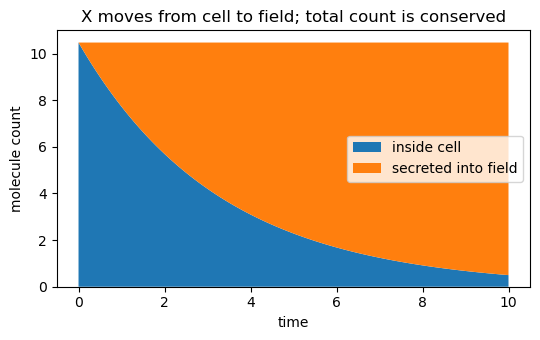

In [11]:
efflux = Reaction(
    {"X": 1}, {}, exports={"X": 1},
    rate_law_type="mass_action", rate_params={"k": 0.3},
)
network = ReactionNetwork("efflux", {"R": efflux})

cell = Cell(
    id=0, position=[50.0, 50.0], orientation=[1.0, 0.0],
    network=network, growth_rate=0.0, rng=np.random.default_rng(0),
)
cell.set_concentration("X", 5.0)

field  = Field("X", np.zeros((20, 20)))
env    = Environment("Secretion Demo", shape=(20, 20), fields=[field])
colony = Colony([cell], env)

# Colony.step() is the package method to advance time;
# we record field values each step since Simulation only records cell state.
dt, t_max = 0.1, 10.0
times, cell_copies, field_copies = [0.0], [cell.copy_number("X")], [0.0]
t = 0.0
while t < t_max - 1e-9:
    colony.step(dt)
    t += dt
    times.append(t)
    cell_copies.append(cell.copy_number("X"))
    field_copies.append(env.get_field("X").values.sum() * env.grid_cell_volume)

plt.figure(figsize=(5.5, 3.5))
plt.stackplot(times, cell_copies, field_copies,
              labels=["inside cell", "secreted into field"])
plt.xlabel("time")
plt.ylabel("molecule count")
plt.title("X moves from cell to field; total count is conserved")
plt.legend(loc="center right")
plt.tight_layout()
plt.show()


## 11. Survival conditions: nutrient-limited death

`Colony(..., survival_conditions=[(species, operator, threshold), ...])`
kills any cell whose concentration violates a condition. Here several
non-growing cells each consume a fixed nutrient pool at the same rate;
staggered starting amounts give a staggered die-off.


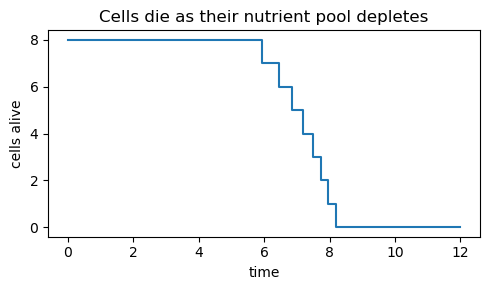

In [12]:
consumption = Reaction({"nutrient": 1}, {}, rate_law_type="mass_action", rate_params={"k": 0.5})
network = ReactionNetwork("consumption", {"R": consumption})

cells = [
    Cell(
        id=i, position=[10.0 + 5.0*i, 30.0], orientation=[1.0, 0.0],
        network=network, growth_rate=0.0, rng=np.random.default_rng(100+i),
    )
    for i in range(8)
]
for i, c in enumerate(cells):
    c.set_concentration("nutrient", 1.0 + 0.3*i)

colony = Colony(cells, Environment("Nutrient Demo", shape=(5,5), bounds=(60.,60.)),
                survival_conditions=[("nutrient", ">", 0.05)])
sim = Simulation(colony, dt=0.05, t_max=12.0)
df  = sim.run(show_progress=False)

alive_over_time = df.groupby("time")["alive"].sum()
plt.figure(figsize=(5, 3))
plt.step(alive_over_time.index, alive_over_time.values, where="post")
plt.xlabel("time")
plt.ylabel("cells alive")
plt.title("Cells die as their nutrient pool depletes")
plt.tight_layout()
plt.show()


## 12. A growing colony: Brownian motion, contact forces, division

Two cells placed close together grow, divide, and physically push each
other apart as the colony expands. `visualize()` renders every frame ahead
of time and can save the animation as a GIF; the red-tinted margin marks
the area outside `environment.bounds`.


100%|██████████| 150/150 [00:00<00:00, 948.15it/s] 


grew from 2 to 19 living cells


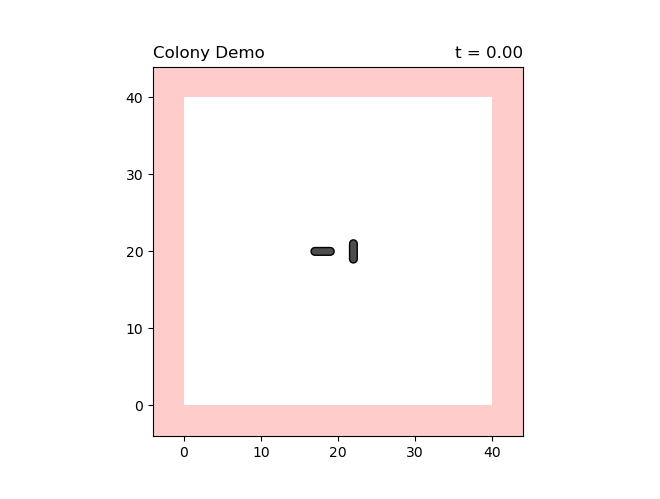

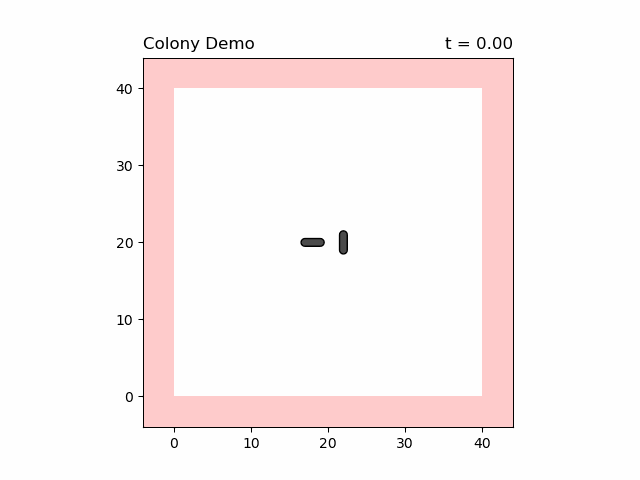

In [13]:
env = Environment("Colony Demo", shape=(10, 10), bounds=(40.0, 40.0))
colony_cells = [
    Cell(id=0, position=[18.0, 20.0], orientation=[1.0, 0.0], length=2.0, rng=np.random.default_rng(1)),
    Cell(id=1, position=[22.0, 20.0], orientation=[0.0, 1.0], length=2.0, rng=np.random.default_rng(2)),
]
colony = Colony(colony_cells, env, k=10.0, drag=1.0)

sim = Simulation(colony, dt=0.02, t_max=3.0)
df  = sim.run()
print(f"grew from 2 to {int(df[df['time'] == df['time'].max()]['alive'].sum())} living cells")

visualize(sim, interval=80, save_path="outputs", filename="colony.gif", show_progress=False)
Image(filename="outputs/colony.gif")


## 13. Cell coloration: an A → B → C cascade

`visualize(..., red=, green=, blue=)` colors each cell by its concentration
of up to three named species, each channel normalized by that species' own
peak over the whole simulation. A cascade `A -> B -> C` with well-separated
rate constants (`k1 >> k2`) sweeps every cell from red, through green, to
blue.


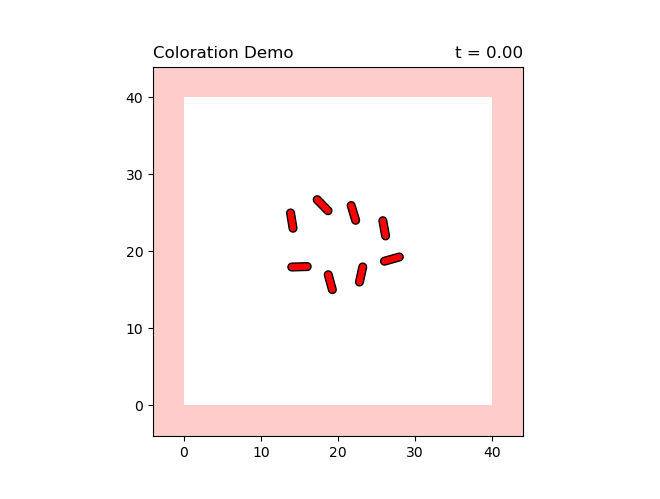

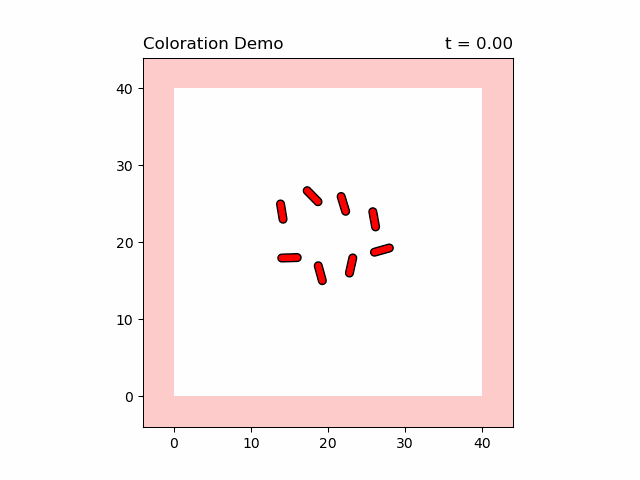

In [14]:
rng = np.random.default_rng(7)
cluster_positions = [
    [14.0, 24.0], [18.0, 26.0], [22.0, 25.0], [26.0, 23.0],
    [15.0, 18.0], [19.0, 16.0], [23.0, 17.0], [27.0, 19.0],
]

cascade_cells = []
for i, position in enumerate(cluster_positions):
    k1 = rng.normal(3.0, 0.4)
    k2 = rng.normal(0.4, 0.05)
    step1 = Reaction({"A": 1}, {"B": 1}, rate_law_type="mass_action", rate_params={"k": k1})
    step2 = Reaction({"B": 1}, {"C": 1}, rate_law_type="mass_action", rate_params={"k": k2})
    network = ReactionNetwork("cascade", {"step1": step1, "step2": step2})
    angle = rng.uniform(0, 2*np.pi)
    cell = Cell(
        id=i, position=position, orientation=[np.cos(angle), np.sin(angle)],
        length=2.0, network=network, growth_rate=0.0, rng=np.random.default_rng(1000+i),
    )
    cell.set_concentration("A", 1.0)
    cascade_cells.append(cell)

colony = Colony(cascade_cells, Environment("Coloration Demo", shape=(10,10), bounds=(40.,40.)), k=10.0, drag=1.0)
sim = Simulation(colony, dt=0.08, t_max=10.0)
sim.run(show_progress=False)

visualize(sim, red="A", green="B", blue="C",
          interval=80, save_path="outputs", filename="cascade.gif", show_progress=False)
Image(filename="outputs/cascade.gif")


## 14. `run_replicates`: parallel stochastic replicates

Division noise (the adder model's random increment) makes each
`Simulation` one sample from a distribution. `run_replicates` runs many
independent colonies across CPU cores and returns one combined DataFrame.


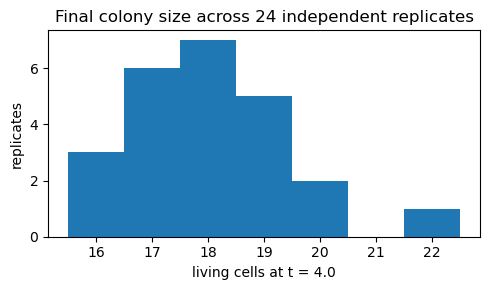

In [15]:
def build_colony(replicate_id):
    import numpy as np
    from multicellular import Cell, Colony, Environment
    env  = Environment("Multithreading Demo", shape=(10, 10), bounds=(40.0, 40.0))
    cell = Cell(
        id=0, position=[20.0, 20.0], orientation=[1.0, 0.0], length=2.0,
        cv_delta=0.15, rng=np.random.default_rng(replicate_id),
    )
    return Colony([cell], env)

replicates_df = run_replicates(build_colony, n_replicates=24, dt=0.05, t_max=4.0)

final_time   = replicates_df["time"].max()
final_counts = (
    replicates_df[replicates_df["time"] == final_time]
    .groupby("replicate_id")["alive"]
    .sum()
)

plt.figure(figsize=(5, 3))
plt.hist(final_counts, bins=np.arange(final_counts.min(), final_counts.max()+2) - 0.5)
plt.xlabel("living cells at t = 4.0")
plt.ylabel("replicates")
plt.title(f"Final colony size across {len(final_counts)} independent replicates")
plt.tight_layout()
plt.show()


## 15. Changing inducer concentration over time: a Plac-driven reporter

Putting it together: a cell expresses GFP from a Plac-like promoter (the
`hill_langmuir` rate law from section 2), modeled as activated by an
inducer (e.g. IPTG) that relieves repression. The cell starts in a medium
with no IPTG (basal expression only); after running the simulation, we
swap in a new `Environment` whose `IPTG` field is uniformly nonzero via
`colony.switch_environment()`, then call `sim.run()` again with a larger
`t_max` to continue.


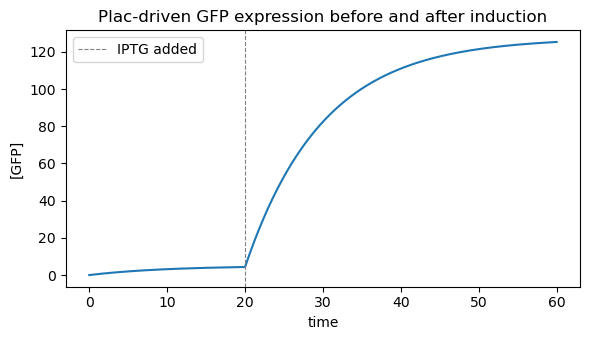

In [16]:
transcription = Reaction(
    {}, {"GFP": 1}, catalysts=["RNAP", "IPTG"],
    rate_law_type="hill_langmuir",
    rate_params={"alpha": 50.0, "beta": 0.5, "C": 1.0, "n": 2},
)
degradation = Reaction({"GFP": 1}, {}, rate_law_type="mass_action", rate_params={"k": 0.1})
network = ReactionNetwork("Plac_GFP", {"transcription": transcription, "degradation": degradation})

shape = (5, 5)
cell  = Cell(
    id=0, position=[50.0, 50.0], orientation=[1.0, 0.0],
    network=network, growth_rate=0.0, rng=np.random.default_rng(0),
)
cell.set_concentration("RNAP", 1.0)

colony = Colony([cell], Environment("No Induction", shape=shape))

induction_time = 20.0
sim = Simulation(colony, dt=0.1, t_max=induction_time)
sim.run(show_progress=False)

# Add IPTG and continue the simulation
colony.switch_environment(Environment("+IPTG", shape=shape, fields=[
    Field("IPTG", np.full(shape, 1.0), is_chemical=True)
]))
df = sim.run(t_max=induction_time + 40.0, show_progress=False)

plt.figure(figsize=(6, 3.5))
plt.plot(df["time"], df["GFP"])
plt.axvline(induction_time, color="gray", linestyle="--", linewidth=0.8, label="IPTG added")
plt.xlabel("time")
plt.ylabel("[GFP]")
plt.title("Plac-driven GFP expression before and after induction")
plt.legend()
plt.tight_layout()
plt.show()

with open("outputs/plac_gfp_simulation.pkl", "wb") as f:
    pickle.dump(df, f)
